# 读取配置文件

In [59]:
from config_utils import api_key,base_url
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate


template = ""
prompt = PromptTemplate.format_prompt(template)

chat_minimax_model = ChatOpenAI(
    model="Pro/MiniMaxAI/MiniMax-M2.5",
    api_key=api_key,
    base_url=base_url,
    streaming=True
)

chat_GLM_model=ChatOpenAI(
    model="Pro/zai-org/GLM-5.1",
    api_key=api_key,
    base_url=base_url,
    streaming=True
)

models = {
    "mini_max":chat_minimax_model,
    "GLM":chat_GLM_model
}

agent = create_agent(
    model=chat_minimax_model,
    tools=[],
    middleware=[],
    system_prompt=f"{prompt}",
)

# 构建state/node/graph

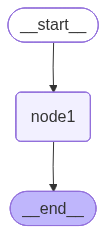

In [60]:
from langgraph.graph import StateGraph,START,END
from typing import Annotated,Sequence
from pydantic import BaseModel,Field
from IPython.display import Image,display
from langchain_core.messages import BaseMessage,AIMessage,HumanMessage
import operator
from langchain_core.runnables import RunnableConfig

class State(BaseModel):
    messages:Annotated[Sequence[BaseMessage],operator.add]


def node1(state:State,config:RunnableConfig) -> dict:
    model_name = config["configurable"].get("model","mini_max")
    model = models[model_name]
    response = model.invoke(state.messages)

    return {
        "messages":[response]
    }



graph_builder = StateGraph(State)
graph_builder.add_node("node1",node1)


graph_builder.add_edge(START,"node1")
graph_builder.add_edge("node1",END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [61]:
result = graph.invoke(
     input={
        "messages": [HumanMessage(content="who are you")]
    },
    config={
    "configurable":{
        "model":"mini_max"
    }}
)
print(result['messages'][1].response_metadata['model_name'])

Pro/MiniMaxAI/MiniMax-M2.5


In [62]:
config = {
    "configurable":{
        "model":"GLM"
    }
}
result = graph.invoke(
     input={
        "messages": [HumanMessage(content="who are you")]
    },
    config=config
)
print(result['messages'][1].response_metadata['model_name'])

Pro/zai-org/GLM-5.1
